In [2]:
import pandas
from collections import Counter
from matplotlib import pyplot as plt

In [3]:
df = pandas.read_excel('Product-Sales-Region.xlsx')
df.describe()

,Date,Quantity,UnitPrice,Discount,TotalPrice,Returned,ShippingCost,OrderDate,DeliveryDate
count,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500
mean,2024-04-07 21:35:02.400000256,10.410667,298.826947,0.073133,2919.994952,0.248000,27.507293,2024-04-07 21:35:02.400000256,2024-04-13 22:36:28.799999744
min,2023-01-01 00:00:00,1.000000,5.520000,0.000000,6.970000,0.000000,5.010000,2023-01-01 00:00:00,2023-01-08 00:00:00
25%,2023-08-20 00:00:00,5.000000,151.020000,0.000000,867.136250,0.000000,16.700000,2023-08-20 00:00:00,2023-08-25 12:00:00
50%,2024-04-08 12:00:00,11.000000,294.740000,0.050000,2174.724000,0.000000,27.100000,2024-04-08 12:00:00,2024-04-15 12:00:00
75%,2024-12-07 06:00:00,15.000000,446.702500,0.100000,4414.723500,0.000000,38.635000,2024-12-07 06:00:00,2024-12-13 06:00:00
max,2025-06-30 00:00:00,20.000000,599.720000,0.150000,11077.000000,1.000000,49.980000,2025-06-30 00:00:00,2025-07-10 00:00:00
std,NaN,5.735732,169.100075,0.055979,2522.789977,0.431996,13.093453,NaN,NaN


In [4]:
df.dtypes

Date             datetime64[ns]
Region                   object
Product                  object
Quantity                  int64
UnitPrice               float64
StoreLocation            object
CustomerType             object
Discount                float64
Salesperson              object
TotalPrice              float64
PaymentMethod            object
Promotion                object
Returned                  int64
OrderID                  object
CustomerName             object
ShippingCost            float64
OrderDate        datetime64[ns]
DeliveryDate     datetime64[ns]
RegionManager            object
dtype: object

First of all, we check for missing values

In [5]:
df.isna().sum()

Date               0
Region             0
Product            0
Quantity           0
UnitPrice          0
StoreLocation      0
CustomerType       0
Discount           0
Salesperson        0
TotalPrice         0
PaymentMethod      0
Promotion        370
Returned           0
OrderID            0
CustomerName       0
ShippingCost       0
OrderDate          0
DeliveryDate       0
RegionManager      0
dtype: int64

There is only one column with missing values, the Promotion Column. And it has 370 missing values. We can drop thhis column and continue with other columns in the dataframe.

In [6]:
df.drop(['Promotion'], axis=1, inplace=True)

In [7]:
df.isna().sum()

Date             0
Region           0
Product          0
Quantity         0
UnitPrice        0
StoreLocation    0
CustomerType     0
Discount         0
Salesperson      0
TotalPrice       0
PaymentMethod    0
Returned         0
OrderID          0
CustomerName     0
ShippingCost     0
OrderDate        0
DeliveryDate     0
RegionManager    0
dtype: int64

Now, no other columns has missing values. We can alo check for duplicate columns in the dataframe

In [8]:
sum(df.duplicated())

0

There are no duplicated rows here, so, we proceed

In [9]:
df.columns

Index(['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation',
       'CustomerType', 'Discount', 'Salesperson', 'TotalPrice',
       'PaymentMethod', 'Returned', 'OrderID', 'CustomerName', 'ShippingCost',
       'OrderDate', 'DeliveryDate', 'RegionManager'],
      dtype='object')

In [10]:
df.head(4)

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron


You can begin anywhere, but let's begin with the sales person that sold the highest number of items.
To do this, we begin with the number of sales persons on the dataset

In [11]:
sales = dict(Counter(df['Salesperson']))
sales

{'Eva': 236,
 'Alice': 259,
 'Frank': 243,
 'Carlos': 270,
 'Diana': 249,
 'Bob': 243}

In [12]:
def sale_quantity(sales_person):
    filt = df['Salesperson'] == sales_person
    sales_person_df = df.loc[filt]
    return [i for i in sales_person_df['Quantity']]


In [13]:
total_sales = {}
for key in sales.keys():
    total_sales[key] = sum(sale_quantity(key))
total_sales  



{'Eva': 2452,
 'Alice': 2732,
 'Frank': 2524,
 'Carlos': 2699,
 'Diana': 2548,
 'Bob': 2661}

In [14]:
persons = [person for person in total_sales.keys()]
sales = [sale for sale in total_sales.values()]
sales_by_person_df = pandas.DataFrame({'persons': persons, 'sales': sales})
sales_by_person_df.sort_values(by='sales', ascending=False)

,persons,sales
1,Alice,2732
3,Carlos,2699
5,Bob,2661
4,Diana,2548
2,Frank,2524
0,Eva,2452


From here, we can see that Alice had the highest sales with 2732 items.

We can visualize the sales records of each of the sales persons on a bar chart

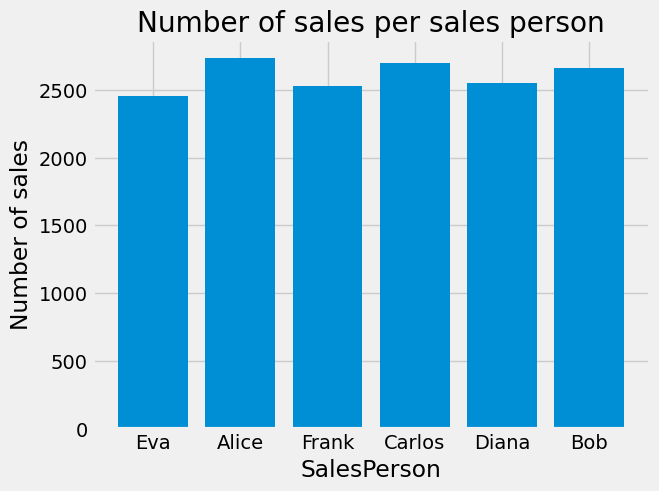

In [15]:
x_axis = [i for i in total_sales.keys()]
y_axis = [total_sales[i] for i in x_axis]
plt.style.use('fivethirtyeight')
plt.xlabel('SalesPerson')
plt.ylabel('Number of sales')
plt.title('Number of sales per sales person')
plt.bar(x_axis, y_axis)
plt.show()

In [16]:
df.head()

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [17]:
def total_amount_by_person(person):
    person_df = df.loc[df['Salesperson'] == person]
    return sum(person_df['TotalPrice'])

total_amount_dict = {}
for sales_person in total_sales.keys():
    total_amount_dict[sales_person] = total_amount_by_person(sales_person)
    

In [18]:
total_amount_df = pandas.DataFrame(
    {
        'Names': total_amount_dict.keys(),
        'TotalAmount': total_amount_dict.values()
    }
)
total_amount_df.sort_values(by='TotalAmount',ascending=False, inplace=True)

In [19]:
total_amount_df

,Names,TotalAmount
5,Bob,796780.5215
1,Alice,786165.8400
2,Frank,714641.5220
3,Carlos,707166.7160
0,Eva,698669.5795
4,Diana,676568.2495


Bob generated the highest amount of money, followed by Alice, Frank, Carlos, Eva and Diana. We can represent this on a piechart

In [20]:
names = [name for name in total_amount_df['Names']]
amounts = [amount for amount in total_amount_df['TotalAmount']]
labels = [f'{names[i]} = {amounts[i]}' for i in range(len(names))]
labels

['Bob = 796780.5214999996',
 'Alice = 786165.8400000002',
 'Frank = 714641.5220000003',
 'Carlos = 707166.7160000007',
 'Eva = 698669.5795000001',
 'Diana = 676568.2495000005']

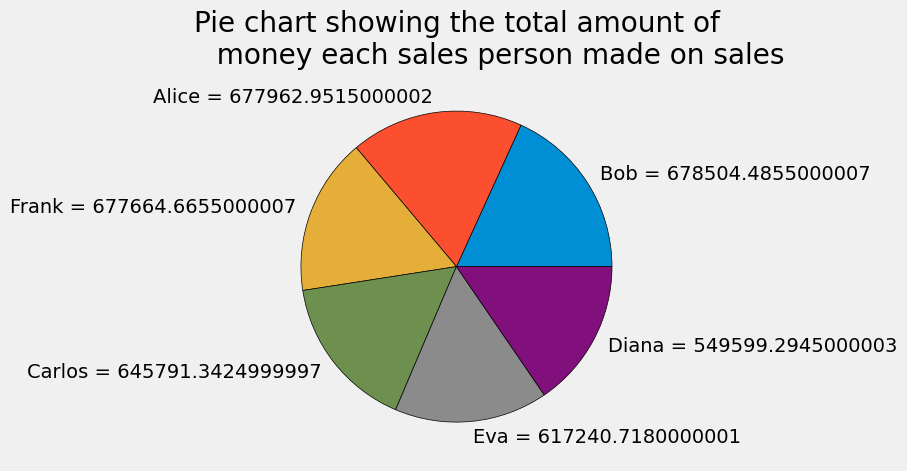

In [38]:
labels = [f'{names[i]} = {amounts[i]}' for i in range(len(names))]
wedgeprops = {'edgecolor': 'black'}
plt.style.use('fivethirtyeight')
plt.title('''Pie chart showing the total amount of
          money each sales person made on sales''')
plt.pie(total_amount_df['TotalAmount'], labels=labels, wedgeprops=wedgeprops)
plt.show()

They look almost the same. A bar chart can help us differentiate each of them

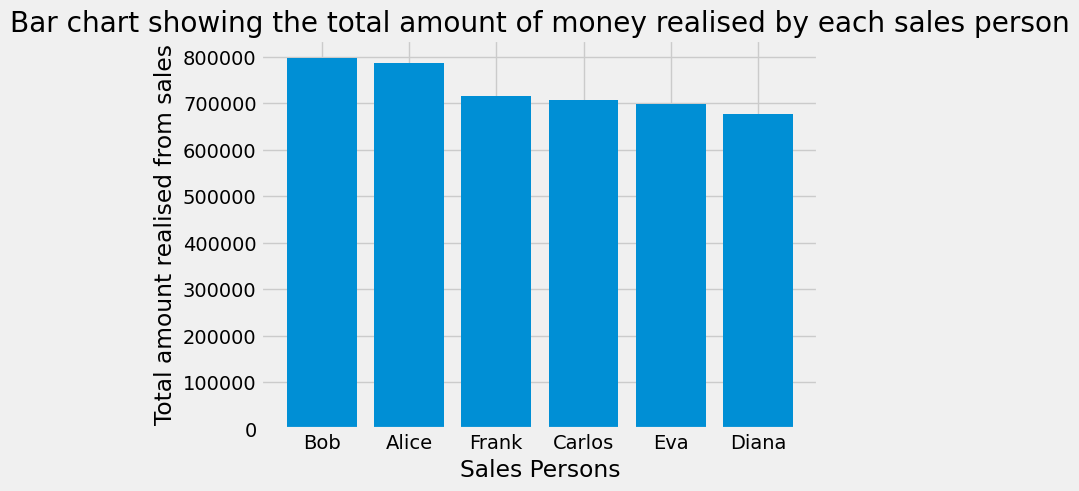

In [22]:
plt.style.use('fivethirtyeight')
plt.xlabel('Sales Persons')
plt.ylabel('Total amount realised from sales')
plt.title('Bar chart showing the total amount of money realised by each sales person')
plt.bar(names, amounts)
plt.show()

The next question we might want to answer is, Which product generated the highest amount of money?

In [23]:
df.head()

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [24]:
def total_revenue_by_product(product):
    product_df = df.loc[df['Product'] == product]
    total_price = sum(product_df['TotalPrice'])
    total_discount = sum(product_df['Discount'])
    total_shipping_cost = sum(product_df['ShippingCost'])
    total_revenue_generated = total_price - total_discount - total_shipping_cost
    return total_revenue_generated 


In [25]:
product_sales = {}
for i in dict(Counter(df['Product'])).keys():
    product_sales[i] = total_revenue_by_product(i)

In [26]:
products_data = pandas.DataFrame(
    {
        'products': [i for i in product_sales.keys()],
        'TotalAmount': [i for i in product_sales.values()]
    }
)
products_data.sort_values(by='TotalAmount', ascending=False, inplace=True)
products_data

,products,TotalAmount
6,Printer,678504.4855
0,Laptop,677962.9515
5,Tablet,677664.6655
4,Monitor,645791.3425
3,Chair,617240.7180
2,Desk,549599.2945
1,Phone,491858.3310


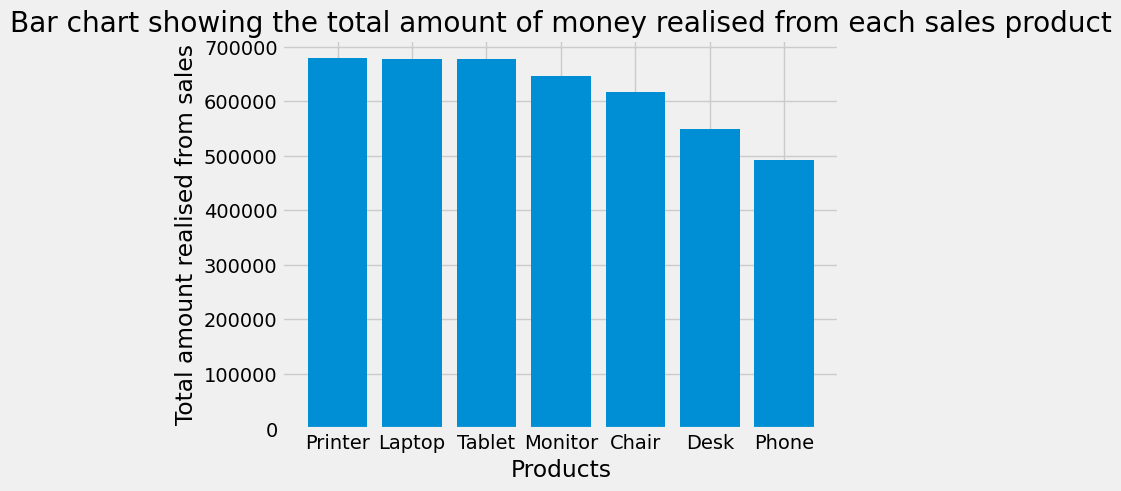

In [27]:
products = [i for i in products_data['products']]
amounts = [i for i in products_data['TotalAmount']]
plt.style.use('fivethirtyeight')
plt.xlabel('Products')
plt.ylabel('Total amount realised from sales')
plt.title('Bar chart showing the total amount of money realised from each sales product')
plt.bar(products, amounts)
plt.show()

Now, we want to findout the products that sold the most in each of the regions

First, lets get all the regions and the prducts

In [28]:
regions = [i for i in dict(Counter(df['Region'])).keys()]
products = [i for i in dict(Counter(df['Product'])).keys()]
products

['Laptop', 'Phone', 'Desk', 'Chair', 'Monitor', 'Tablet', 'Printer']

In [29]:
def product_by_region(region, product):
    region_df = df.loc[df['Region'] == region]
    product_df = region_df.loc[region_df['Product'] == product]
    return sum(product_df['Quantity'])


number_of_products = [product_by_region('East', product) for product in products]

number_of_products



[528, 539, 398, 378, 364, 415, 456]

We can represent this on a dataframe

In [30]:
east_products_df = pandas.DataFrame(
    {
        'Products': products,
        'NumberSold': number_of_products
    }
)

east_products_df.sort_values(by='NumberSold', ascending=False, inplace=True)
east_products_df

,Products,NumberSold
1,Phone,539
0,Laptop,528
6,Printer,456
5,Tablet,415
2,Desk,398
3,Chair,378
4,Monitor,364


We can represent this information on a bar chart

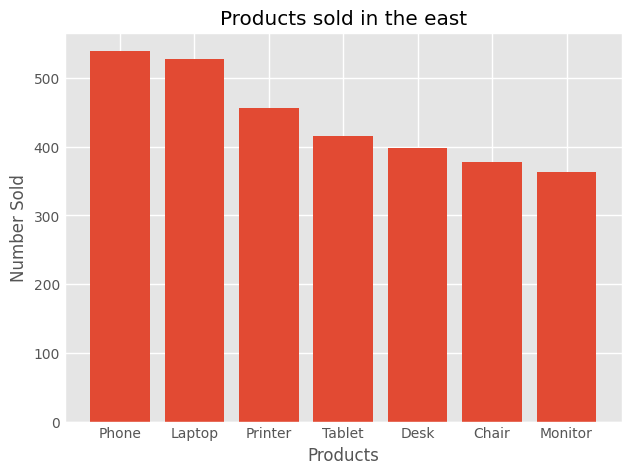

In [31]:
plt.style.use('ggplot')
plt.bar(east_products_df['Products'], east_products_df['NumberSold'])
plt.title('Products sold in the east')
plt.xlabel('Products')
plt.xticks(rotation=0)
plt.ylabel('Number Sold')
plt.show()

So, in the east, Phone was the most sold product, followed by Laptop, Printer, etc

We can automate this process to give us the  chart of all the products sold in the different regions at the same time

In [32]:
regions

['East', 'South', 'North', 'Central', 'West']

In [33]:
list_region_products = []
for region in regions:
    number_of_products = [product_by_region(region, product) for product in products]
    region_products_df = pandas.DataFrame(
        {
            'Product': products,
            'NumberSold': number_of_products
        }
    )
    region_products_df.sort_values(by='NumberSold', ascending=False, inplace=True)
    list_region_products.append(region_products_df)
    # print(f'In the {region},')
    # print(region_products_df)
    # print()

In [34]:
list_region_products

[   Product  NumberSold
 1    Phone         539
 0   Laptop         528
 6  Printer         456
 5   Tablet         415
 2     Desk         398
 3    Chair         378
 4  Monitor         364,
    Product  NumberSold
 0   Laptop         544
 1    Phone         495
 3    Chair         482
 6  Printer         446
 5   Tablet         385
 4  Monitor         345
 2     Desk         256,
    Product  NumberSold
 2     Desk         581
 5   Tablet         563
 4  Monitor         523
 6  Printer         515
 3    Chair         489
 0   Laptop         418
 1    Phone         353,
    Product  NumberSold
 5   Tablet         578
 6  Printer         489
 0   Laptop         485
 4  Monitor         446
 2     Desk         433
 3    Chair         381
 1    Phone         290,
    Product  NumberSold
 5   Tablet         636
 4  Monitor         499
 0   Laptop         433
 6  Printer         430
 3    Chair         392
 2     Desk         358
 1    Phone         293]

In [35]:
len(list_region_products)

5

In [36]:
list_region_products[1]['Product']

0     Laptop
1      Phone
3      Chair
6    Printer
5     Tablet
4    Monitor
2       Desk
Name: Product, dtype: object

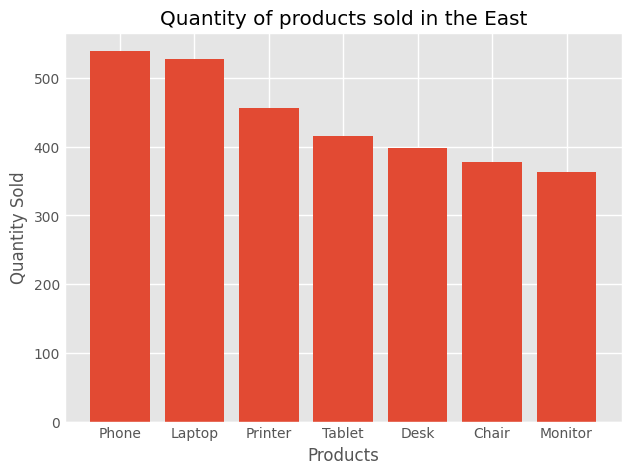

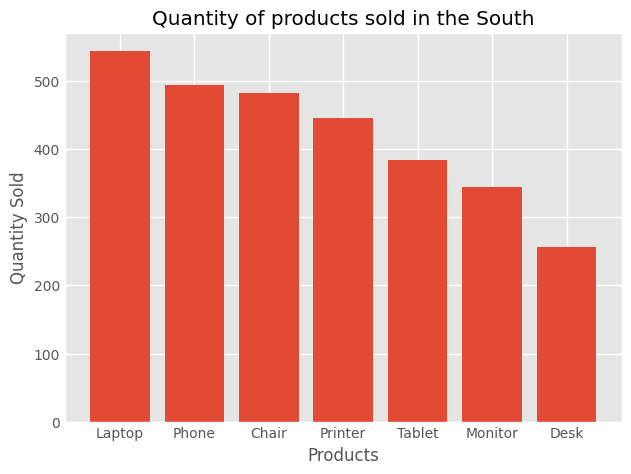

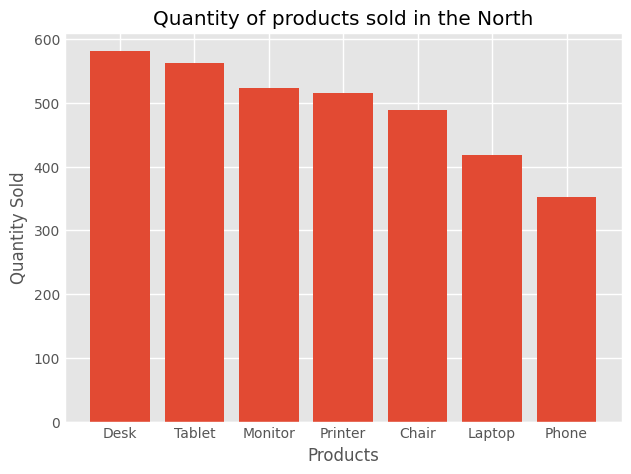

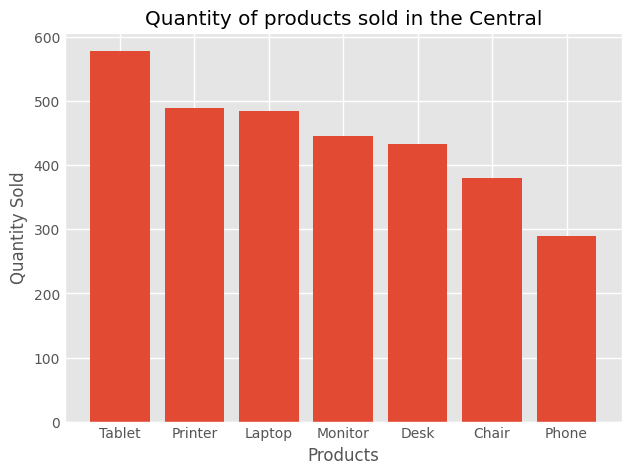

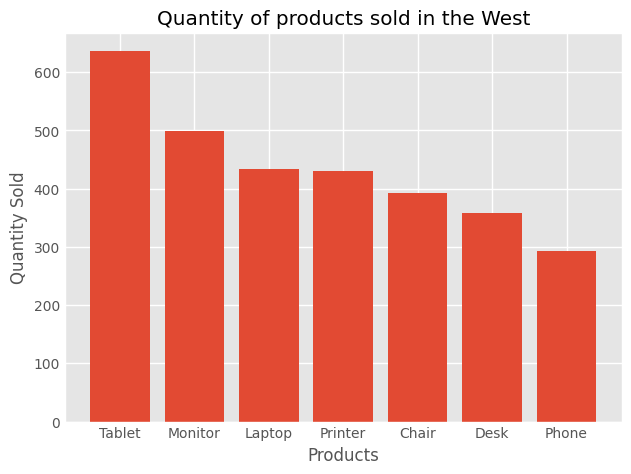

In [37]:
for data in range(len(list_region_products)):
    plt.xlabel('Products')
    plt.ylabel('Quantity Sold')
    plt.title(f'Quantity of products sold in the {regions[data]}')
    plt.bar(list_region_products[data]['Product'], list_region_products[data]['NumberSold'])
    plt.show()

In each of the regions, the highest sold products are as follows:
East: Phone,
South: Laptop,
North: Desk,
Central: Tablet,
West: Tablet